# FIFA WORLD CUP 2026 AI TOURNAMENT SIMULATOR

# Phase 1 — Data Loading & Preprocessing

In [1]:
import pandas as pd
import numpy as np
import random
random.seed(42)
np.random.seed(42)  # Can be removed to make it a simulator

# Load dataset
df = pd.read_csv('/content/matches_1930_2022.csv')

# ============================================
# KEEP ONLY MODERN WORLD CUPS
# ============================================

df = df[df['Year'] >= 2002]

# Reset index
df = df.reset_index(drop=True)

df.head()

,home_team,away_team,home_score,home_xg,home_penalty,away_score,away_xg,away_penalty,home_manager,home_captain,...,home_penalty_shootout_miss_long,away_penalty_shootout_miss_long,home_red_card,away_red_card,home_yellow_red_card,away_yellow_red_card,home_yellow_card_long,away_yellow_card_long,home_substitute_in_long,away_substitute_in_long
0,Argentina,France,3,3.3,4.0,3,2.2,2.0,Lionel Scaloni,Lionel Messi,...,NaN,"['3|1:1|Kingsley Coman', '5|2:1|Aurélien Tchou...",NaN,NaN,NaN,NaN,"['45+7&rsquor;|2:0|Enzo Fernández', '90+8&rsqu...","['55&rsquor;|2:0|Adrien Rabiot', '87&rsquor;|2...",['64&rsquor;|2:0|Marcos Acuña|for Ángel Di Mar...,['41&rsquor;|2:0|Randal Kolo Muani|for Ousmane...
1,Croatia,Morocco,2,0.7,NaN,1,1.2,NaN,Zlatko Dalić,Luka Modrić,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['69&rsquor;|2:1|Azzedine Ounahi', '84&rsquor;...",['61&rsquor;|2:1|Nikola Vlašić|for Andrej Kram...,['46&rsquor;|2:1|Ilias Chair|for Abdelhamid Sa...
2,France,Morocco,2,2.0,NaN,0,0.9,NaN,Didier Deschamps,Hugo Lloris,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['27&rsquor;|1:0|Sofiane Boufal'],['65&rsquor;|1:0|Marcus Thuram|for Olivier Gir...,['21&rsquor;|1:0|Selim Amallah|for Romain Saïs...
3,Argentina,Croatia,3,2.3,NaN,0,0.5,NaN,Lionel Scaloni,Lionel Messi,...,NaN,NaN,NaN,NaN,NaN,NaN,"['68&rsquor;|2:0|Cristian Romero', '71&rsquor;...","['32&rsquor;|0:0|Mateo Kovačić', '32&rsquor;|0...",['62&rsquor;|2:0|Lisandro Martínez|for Leandro...,"['46&rsquor;|2:0|Mislav Oršić|for Borna Sosa',..."
4,Morocco,Portugal,1,1.4,NaN,0,0.9,NaN,Hoalid Regragui,Romain Saïss,...,NaN,NaN,NaN,NaN,Walid Cheddira · 90+3,NaN,"['70&rsquor;|1:0|Achraf Dari', '90+1&rsquor;|1...",['87&rsquor;|1:0|Vitinha'],['57&rsquor;|1:0|Achraf Dari|for Romain Saïss'...,['51&rsquor;|1:0|João Cancelo|for Raphaël Guer...


In [2]:
# Keep only important columns
df = df[
    [
        'home_team',
        'away_team',
        'home_score',
        'away_score',
        'home_xg',
        'away_xg',
        'Year',
        'Round',
        'Host'
    ]
]


In [3]:
# Fill missing xG values with mean
df['home_xg'] = df['home_xg'].fillna(df['home_xg'].mean())
df['away_xg'] = df['away_xg'].fillna(df['away_xg'].mean())


In [4]:
# Create Match Outcome Labels
def get_result(row):
    if row['home_score'] > row['away_score']:
        return 'Home Win'
    elif row['home_score'] < row['away_score']:
        return 'Away Win'
    else:
        return 'Draw'

df['result'] = df.apply(get_result, axis=1)

In [5]:
# Create Goal Difference Feature
df['goal_difference'] = df['home_score'] - df['away_score']

In [6]:
# Create xG Difference Feature
df['xg_difference'] = df['home_xg'] - df['away_xg']


In [7]:
# ============================================
# SORT DATA BY YEAR
# ============================================

df = df.sort_values(by='Year').reset_index(drop=True)

# ============================================
# CREATE EMPTY FEATURE LISTS
# ============================================

home_avg_goals_list = []
away_avg_goals_list = []

home_avg_conceded_list = []
away_avg_conceded_list = []

# ============================================
# BUILD FEATURES USING PAST MATCHES ONLY
# ============================================

for i in range(len(df)):

    current_match = df.iloc[i]

    home_team = current_match['home_team']
    away_team = current_match['away_team']

    # ----------------------------------------
    # PAST MATCHES ONLY
    # ----------------------------------------

    past_matches = df.iloc[:i]

    # ----------------------------------------
    # HOME TEAM PAST STATS
    # ----------------------------------------

    home_past_home = past_matches[
        past_matches['home_team'] == home_team
    ]

    home_avg_goals = home_past_home['home_score'].mean()
    home_avg_conceded = home_past_home['away_score'].mean()

    # ----------------------------------------
    # AWAY TEAM PAST STATS
    # ----------------------------------------

    away_past_away = past_matches[
        past_matches['away_team'] == away_team
    ]

    away_avg_goals = away_past_away['away_score'].mean()
    away_avg_conceded = away_past_away['home_score'].mean()

    # ----------------------------------------
    # HANDLE NaN VALUES
    # ----------------------------------------

    if pd.isna(home_avg_goals):
        home_avg_goals = df['home_score'].mean()

    if pd.isna(home_avg_conceded):
        home_avg_conceded = df['away_score'].mean()

    if pd.isna(away_avg_goals):
        away_avg_goals = df['away_score'].mean()

    if pd.isna(away_avg_conceded):
        away_avg_conceded = df['home_score'].mean()

    # ----------------------------------------
    # SAVE FEATURES
    # ----------------------------------------

    home_avg_goals_list.append(home_avg_goals)
    away_avg_goals_list.append(away_avg_goals)

    home_avg_conceded_list.append(home_avg_conceded)
    away_avg_conceded_list.append(away_avg_conceded)

# ============================================
# ADD FEATURES TO DATAFRAME
# ============================================

df['home_avg_goals'] = home_avg_goals_list
df['away_avg_goals'] = away_avg_goals_list

df['home_avg_conceded'] = home_avg_conceded_list
df['away_avg_conceded'] = away_avg_conceded_list

In [8]:
# ============================================
# Strength Difference Features
# ============================================

df['goal_strength_diff'] = (
    df['home_avg_goals']
    - df['away_avg_goals']
)

df['defense_strength_diff'] = (
    df['away_avg_conceded']
    - df['home_avg_conceded']
)

In [9]:

# ============================================
# TEAM POWER RATINGS
# ============================================

team_strength = {

    # ============================================
    # ELITE FAVORITES
    # ============================================

    "Argentina": 96,
    "France": 96,
    "Spain": 94,
    "Brazil": 93,
    "England": 91,

    # ============================================
    # STRONG CONTENDERS
    # ============================================

    "Portugal": 90,
    "Belgium": 88,
    "Netherlands": 85,
    "Croatia": 84,
    "Uruguay": 84,

    # ============================================
    # GOOD TEAMS
    # ============================================

    "Germany": 78,
    "Switzerland": 82,
    "Japan": 82,
    "Morocco": 82,
    "Colombia": 81,
    "Mexico": 80,
    "Senegal": 80,
    "Sweden": 79,

    # ============================================
    # MID TIER
    # ============================================

    "Austria": 78,
    "Norway": 78,
    "Türkiye": 77,
    "United States": 77,
    "Paraguay": 75,
    "Egypt": 75,
    "Canada": 75,
    "Côte d'Ivoire": 75,
    "Bosnia and Herzegovina": 74,
    "Scotland": 74,
    "Ghana": 74,

    # ============================================
    # LOWER TIER
    # ============================================

    "Saudi Arabia": 72,
    "Qatar": 70,
    "Iraq": 69,
    "Jordan": 68,
    "Uzbekistan": 67,
    "New Zealand": 66,
    "DR Congo": 65,
    "South Africa": 65,
    "Haiti": 64,
    "Cape Verde": 64,
    "Curacao": 63,
    "Panama": 63,
    "Tunisia": 63,
    "IR Iran": 63,
    "Australia": 62,
    "Algeria": 62,
    "Ecuador": 62,
    "Czech Republic": 62,
    "Korea Republic": 61
}

# ============================================
# ADD TEAM STRENGTH FEATURES
# ============================================

df['home_strength'] = df['home_team'].map(
    team_strength
)

df['away_strength'] = df['away_team'].map(
    team_strength
)

# Fill missing strengths
df['home_strength'] = df[
    'home_strength'
].fillna(75)

df['away_strength'] = df[
    'away_strength'
].fillna(75)

# Strength difference
df['strength_difference'] = (
    df['home_strength']
    - df['away_strength']
)

In [10]:
# Check Dataset
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (384, 21)

Missing Values:
home_team                0
away_team                0
home_score               0
away_score               0
home_xg                  0
away_xg                  0
Year                     0
Round                    0
Host                     0
result                   0
goal_difference          0
xg_difference            0
home_avg_goals           0
away_avg_goals           0
home_avg_conceded        0
away_avg_conceded        0
goal_strength_diff       0
defense_strength_diff    0
home_strength            0
away_strength            0
strength_difference      0
dtype: int64

First 5 Rows:


,home_team,away_team,home_score,away_score,home_xg,away_xg,Year,Round,Host,result,...,xg_difference,home_avg_goals,away_avg_goals,home_avg_conceded,away_avg_conceded,goal_strength_diff,defense_strength_diff,home_strength,away_strength,strength_difference
0,Korea Republic,United States,1,1,1.435937,1.192187,2002,Group stage,"Korea Republic, Japan",Draw,...,0.24375,1.364583,1.148438,1.148438,1.364583,0.216146,0.216146,61.0,77.0,-16.0
1,Tunisia,Belgium,1,1,1.435937,1.192187,2002,Group stage,"Korea Republic, Japan",Draw,...,0.24375,1.364583,1.148438,1.148438,1.364583,0.216146,0.216146,63.0,88.0,-25.0
2,Portugal,Poland,4,0,1.435937,1.192187,2002,Group stage,"Korea Republic, Japan",Home Win,...,0.24375,1.364583,1.148438,1.148438,1.364583,0.216146,0.216146,90.0,75.0,15.0
3,Mexico,Ecuador,2,1,1.435937,1.192187,2002,Group stage,"Korea Republic, Japan",Home Win,...,0.24375,1.364583,1.148438,1.148438,1.364583,0.216146,0.216146,80.0,62.0,18.0
4,Costa Rica,Türkiye,1,1,1.435937,1.192187,2002,Group stage,"Korea Republic, Japan",Draw,...,0.24375,1.364583,1.148438,1.148438,1.364583,0.216146,0.216146,75.0,77.0,-2.0


# Phase 2 — Feature Encoding & Data Preparation

In [11]:
# essintial libraries for phase 2
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [12]:
# ============================================
# LABEL ENCODING FOR TEAMS
# ============================================

from sklearn.preprocessing import LabelEncoder

# Create encoder
team_encoder = LabelEncoder()

# Fit on all teams
all_teams = pd.concat([

    df['home_team'],

    df['away_team']

])

team_encoder.fit(all_teams)

# Encode teams
df['home_team_encoded'] = team_encoder.transform(
    df['home_team']
)

df['away_team_encoded'] = team_encoder.transform(
    df['away_team']
)

In [13]:
# ============================================
# FEATURE SELECTION
# ============================================

X = df[[

    'home_team_encoded',
    'away_team_encoded',

    'home_xg',
    'away_xg',

    'home_avg_goals',
    'away_avg_goals',

    'home_avg_conceded',
    'away_avg_conceded',

    'goal_strength_diff',
    'defense_strength_diff',

    'Year',

    'strength_difference'
]]

# ============================================
# TARGET LABELS
# ============================================

result_encoder = LabelEncoder()

y = result_encoder.fit_transform(
    df['result']
)

In [14]:
# Train/Test Split (Time-Series Safe)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [15]:
# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
# Check Results
print("Training Set Shape:", X_train_scaled.shape)
print("Testing Set Shape:", X_test_scaled.shape)

print("\nClass Distribution:")
print(pd.Series(y_train).value_counts())

print("\nFeature Columns:")
print(X.columns)

Training Set Shape: (307, 12)
Testing Set Shape: (77, 12)

Class Distribution:
2    130
0    108
1     69
Name: count, dtype: int64

Feature Columns:
Index(['home_team_encoded', 'away_team_encoded', 'home_xg', 'away_xg',
       'home_avg_goals', 'away_avg_goals', 'home_avg_conceded',
       'away_avg_conceded', 'goal_strength_diff', 'defense_strength_diff',
       'Year', 'strength_difference'],
      dtype='object')


# Phase 3 — Exploratory Data Analysis (EDA) 📈

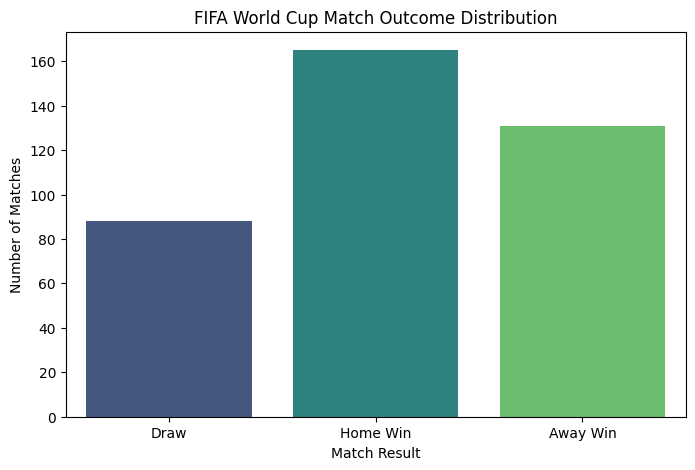

In [17]:
# ============================================
# Match Outcome Distribution
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(
    x='result',
    data=df,
    hue='result',
    palette='viridis',
    legend=False
)

plt.title('FIFA World Cup Match Outcome Distribution')
plt.xlabel('Match Result')
plt.ylabel('Number of Matches')

plt.show()

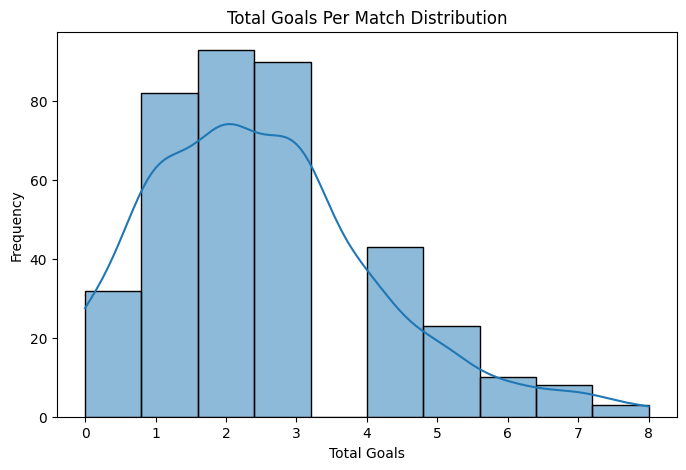

In [18]:
# ============================================
# Goals Distribution
# ============================================

plt.figure(figsize=(8,5))

sns.histplot(df['home_score'] + df['away_score'], bins=10, kde=True)

plt.title('Total Goals Per Match Distribution')
plt.xlabel('Total Goals')
plt.ylabel('Frequency')

plt.show()

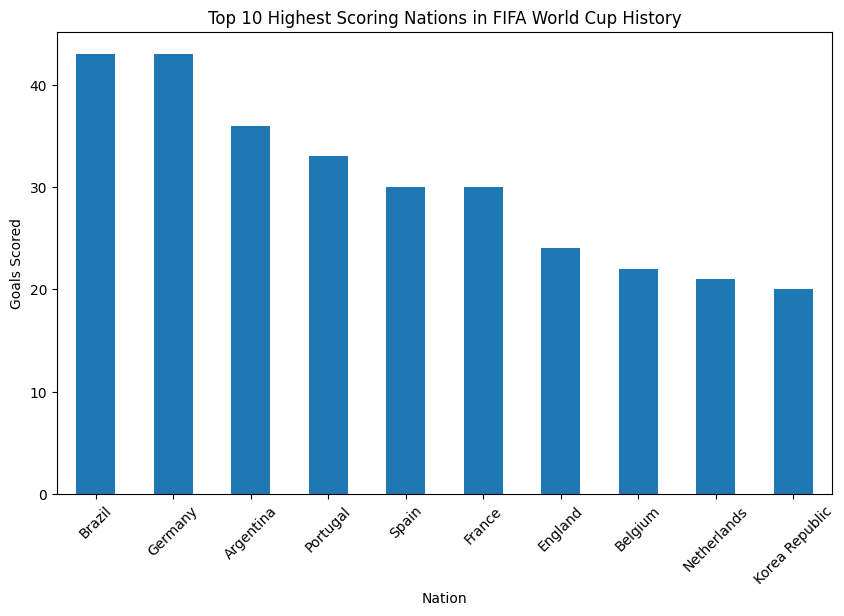

In [19]:
# ============================================
# Top Scoring Teams
# ============================================

top_scoring = df.groupby('home_team')['home_score'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

top_scoring.plot(kind='bar')

plt.title('Top 10 Highest Scoring Nations in FIFA World Cup History')
plt.xlabel('Nation')
plt.ylabel('Goals Scored')
plt.xticks(rotation=45)

plt.show()

# Phase 4 — Train Machine Learning Models 🤖⚽

### Tuned KNN Model

In [20]:
# essential libraries for knn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV


In [21]:
# Hyperparameter Grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}


In [22]:
# Grid Search
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=3,
    verbose=2
)

In [23]:
# Train Model
grid_knn.fit(X_train_scaled, y_train)
# Best Parameters
print("Best Parameters:")
print(grid_knn.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=5, weights=uniform; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=5, weights=uniform; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=5, weights=uniform; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=5, weights=distance; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=5, weights=distance; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=5, weig

In [24]:
# Predictions
y_pred_knn = grid_knn.predict(X_test_scaled)
# Evaluation
print("\nKNN Accuracy:")
print(accuracy_score(y_test, y_pred_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))


KNN Accuracy:
0.45454545454545453

Classification Report:
              precision    recall  f1-score   support

           0       0.34      0.70      0.46        23
           1       0.00      0.00      0.00        19
           2       0.68      0.54      0.60        35

    accuracy                           0.45        77
   macro avg       0.34      0.41      0.35        77
weighted avg       0.41      0.45      0.41        77


Confusion Matrix:
[[16  1  6]
 [16  0  3]
 [15  1 19]]


### Tuned SVM Model

In [25]:
# essential libraries for svm
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


In [26]:
# Hyperparameter Grid
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [1, 0.1, 0.01],
    'kernel': ['rbf']
}

In [27]:
# Grid Search
grid = GridSearchCV(
    SVC(
        probability=True,
        class_weight='balanced'
    ),
    param_grid,
    refit=True,
    verbose=2,
    cv=3
)

In [28]:
# Train Model
grid.fit(X_train_scaled, y_train)
# Best Parameters
print("Best Parameters:")
print(grid.best_params_)


Fitting 3 folds for each of 9 candidates, totalling 27 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.1s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.1s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ...........................C=1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END ...........................C=1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END ...........................C=1, gamma=1,

In [29]:
# Predictions
y_pred_svm = grid.predict(X_test_scaled)
# Evaluation
print("\nSVM Accuracy:")
print(accuracy_score(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))


SVM Accuracy:
0.45454545454545453

Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.65      0.45        23
           1       0.00      0.00      0.00        19
           2       0.65      0.57      0.61        35

    accuracy                           0.45        77
   macro avg       0.33      0.41      0.35        77
weighted avg       0.40      0.45      0.41        77


Confusion Matrix:
[[15  2  6]
 [14  0  5]
 [14  1 20]]


### MLP Neural Network

In [30]:
# essential libraries for MLP
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


In [31]:
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

# Apply SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print(pd.Series(y_train_smote).value_counts())

1    130
2    130
0    130
Name: count, dtype: int64


In [32]:
# Hyperparameter Grid
param_grid_mlp = {
    'hidden_layer_sizes': [
        (64,),
        (128,),
        (64,32),
        (128,64)
    ],

    'activation': [
        'relu',
        'tanh'
    ],

    'alpha': [
        0.0001,
        0.001,
        0.01
    ],

    'learning_rate_init': [
        0.001,
        0.01
    ]
}


In [33]:
# Create Base MLP Model
mlp = MLPClassifier(
    max_iter=2000,
    early_stopping=True,
    random_state=42
)


In [34]:
# Grid Search
grid_mlp = GridSearchCV(
    mlp,
    param_grid_mlp,
    cv=3,
    verbose=2,
    n_jobs=-1
)


In [35]:
# Train Model
grid_mlp.fit(X_train_smote, y_train_smote)
# Best Parameters
print("Best Parameters:")
print(grid_mlp.best_params_)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best Parameters:
{'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.001}


In [36]:
# Predictions
y_pred_mlp = grid_mlp.predict(X_test_scaled)
# Evaluation
print("\nMLP Accuracy:")
print(accuracy_score(y_test, y_pred_mlp))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_mlp,
        target_names=result_encoder.classes_
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_mlp))


MLP Accuracy:
0.5064935064935064

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.40      0.70      0.51        23
        Draw       0.00      0.00      0.00        19
    Home Win       0.64      0.66      0.65        35

    accuracy                           0.51        77
   macro avg       0.35      0.45      0.39        77
weighted avg       0.41      0.51      0.45        77


Confusion Matrix:
[[16  0  7]
 [13  0  6]
 [11  1 23]]


### Random Forest:

Balanced Class Distribution:

1    130
2    130
0    130
Name: count, dtype: int64
Fitting 3 folds for each of 96 candidates, totalling 288 fits

BEST PARAMETERS

{'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

RANDOM FOREST RESULTS

Accuracy:

0.5194805194805194

Classification Report:

              precision    recall  f1-score   support

    Away Win       0.44      0.83      0.58        23
        Draw       0.17      0.05      0.08        19
    Home Win       0.71      0.57      0.63        35

    accuracy                           0.52        77
   macro avg       0.44      0.48      0.43        77
weighted avg       0.50      0.52      0.48        77


FEATURE IMPORTANCE

                  Feature  Importance
11    strength_difference    0.154807
0       home_team_encoded    0.116781
1       away_team_encoded    0.106856
8      goal_strength_diff    0.104901
9   defense_strength_diff    0

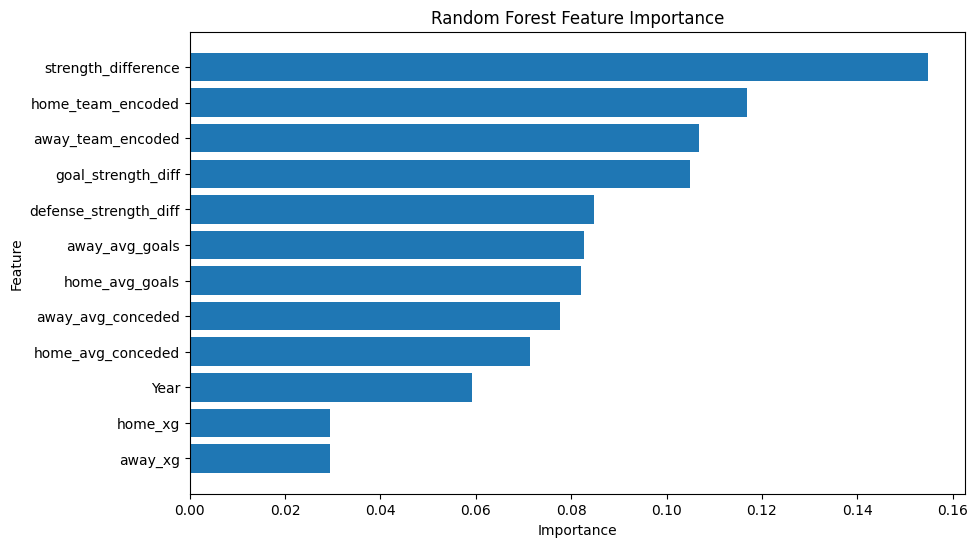

In [37]:
# ============================================
# RANDOM FOREST
# ============================================

# --------------------------------------------
#  IMPORT LIBRARIES
# --------------------------------------------
!pip install imbalanced-learn

import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import GridSearchCV

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt

# ============================================
# APPLY SMOTE
# ============================================

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

# Check balanced classes
print("Balanced Class Distribution:\n")
print(pd.Series(y_train_smote).value_counts())

# ============================================
# RANDOM FOREST MODEL
# ============================================

rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

# ============================================
# HYPERPARAMETER GRID
# ============================================

param_grid_rf = {

    'n_estimators': [100, 200],

    'max_depth': [5, 10, None],

    'min_samples_split': [2, 5],

    'min_samples_leaf': [1, 2],

    'criterion': ['gini', 'entropy'],

    'max_features': ['sqrt', 'log2']

}

# ============================================
# GRID SEARCH
# ============================================

grid_rf = GridSearchCV(

    estimator=rf,

    param_grid=param_grid_rf,

    cv=3,

    scoring='f1_macro',

    n_jobs=-1,

    verbose=2

)

# ============================================
# TRAIN MODEL
# ============================================

grid_rf.fit(
    X_train_smote,
    y_train_smote
)

# ============================================
# BEST PARAMETERS
# ============================================

print("\n===================================")
print("BEST PARAMETERS")
print("===================================\n")

print(grid_rf.best_params_)

# ============================================
# PREDICTIONS
# ============================================

y_pred_rf = grid_rf.predict(X_test_scaled)

# ============================================
# EVALUATION
# ============================================

print("\n===================================")
print("RANDOM FOREST RESULTS")
print("===================================\n")

print("Accuracy:\n")
print(accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=result_encoder.classes_,
        zero_division=0
    )
)

# ============================================
# FEATURE IMPORTANCE
# ============================================

feature_importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': grid_rf.best_estimator_.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\n===================================")
print("FEATURE IMPORTANCE")
print("===================================\n")

print(feature_importance)

# ============================================
# FEATURE IMPORTANCE PLOT
# ============================================

plt.figure(figsize=(10,6))

plt.barh(

    feature_importance['Feature'],

    feature_importance['Importance']

)

plt.xlabel('Importance')

plt.ylabel('Feature')

plt.title('Random Forest Feature Importance')

plt.gca().invert_yaxis()

plt.show()

XGBOOST :

Balanced Class Distribution:

1    130
2    130
0    130
Name: count, dtype: int64
Fitting 3 folds for each of 72 candidates, totalling 216 fits

BEST PARAMETERS

{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

XGBOOST RESULTS

Accuracy:

0.5194805194805194

Classification Report:

              precision    recall  f1-score   support

    Away Win       0.47      0.83      0.60        23
        Draw       0.22      0.11      0.14        19
    Home Win       0.68      0.54      0.60        35

    accuracy                           0.52        77
   macro avg       0.46      0.49      0.45        77
weighted avg       0.51      0.52      0.49        77


XGBOOST FEATURE IMPORTANCE

                  Feature  Importance
2                 home_xg    0.136338
3                 away_xg    0.105720
11    strength_difference    0.104148
0       home_team_encoded    0.083310
5          away_avg_goals    0.080755
8      goal_strength_di

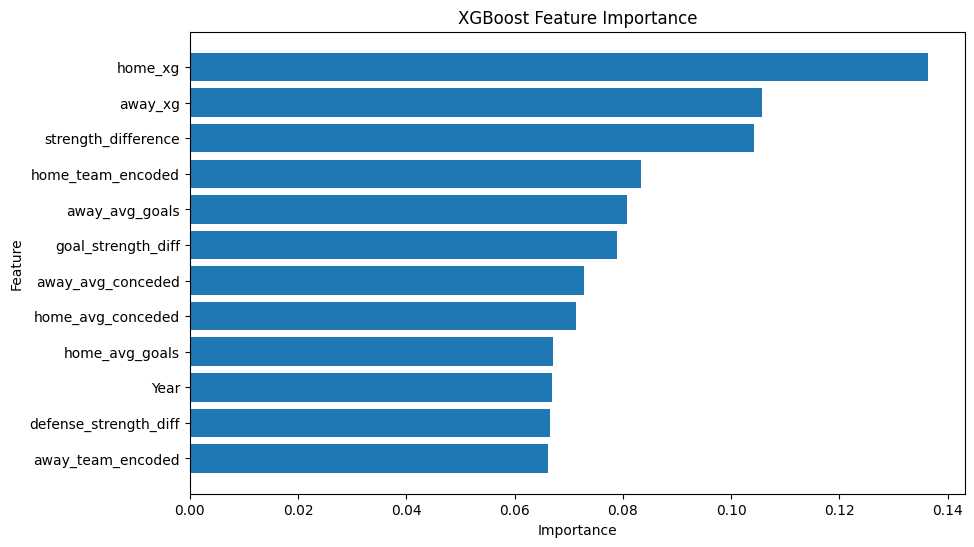

In [38]:
# ============================================
# XGBOOST
# ============================================

# --------------------------------------------
# INSTALL XGBOOST
# --------------------------------------------
!pip install xgboost

# --------------------------------------------
# IMPORT LIBRARIES
# --------------------------------------------
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.model_selection import GridSearchCV

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import pandas as pd

# ============================================
# APPLY SMOTE
# ============================================

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Balanced Class Distribution:\n")
print(pd.Series(y_train_smote).value_counts())

# ============================================
# XGBOOST MODEL
# ============================================

xgb = XGBClassifier(

    objective='multi:softprob',

    num_class=3,

    random_state=42,

    eval_metric='mlogloss'

)

# ============================================
# HYPERPARAMETER GRID
# ============================================

param_grid_xgb = {

    'n_estimators': [100, 200],

    'max_depth': [3, 5, 7],

    'learning_rate': [0.01, 0.05, 0.1],

    'subsample': [0.8, 1.0],

    'colsample_bytree': [0.8, 1.0]

}

# ============================================
# GRID SEARCH
# ============================================

grid_xgb = GridSearchCV(

    estimator=xgb,

    param_grid=param_grid_xgb,

    cv=3,

    scoring='f1_macro',

    verbose=2,

    n_jobs=-1

)

# ============================================
# TRAIN MODEL
# ============================================

grid_xgb.fit(
    X_train_smote,
    y_train_smote
)

# ============================================
# BEST PARAMETERS
# ============================================

print("\n===================================")
print("BEST PARAMETERS")
print("===================================\n")

print(grid_xgb.best_params_)

# ============================================
# PREDICTIONS
# ============================================

y_pred_xgb = grid_xgb.predict(X_test_scaled)

# ============================================
# EVALUATION
# ============================================

print("\n===================================")
print("XGBOOST RESULTS")
print("===================================\n")

print("Accuracy:\n")

print(
    accuracy_score(
        y_test,
        y_pred_xgb
    )
)

print("\nClassification Report:\n")

print(  classification_report(
        y_test,
        y_pred_xgb,
        target_names=result_encoder.classes_,
        zero_division=0   )

)

# ============================================
# FEATURE IMPORTANCE
# ============================================

feature_importance_xgb = pd.DataFrame({

    'Feature': X.columns,

    'Importance': grid_xgb.best_estimator_.feature_importances_

})

feature_importance_xgb = feature_importance_xgb.sort_values(

    by='Importance',

    ascending=False

)

print("\n===================================")
print("XGBOOST FEATURE IMPORTANCE")
print("===================================\n")

print(feature_importance_xgb)

# ============================================
# FEATURE IMPORTANCE PLOT
# ============================================

plt.figure(figsize=(10,6))

plt.barh(

    feature_importance_xgb['Feature'],

    feature_importance_xgb['Importance']

)

plt.xlabel('Importance')

plt.ylabel('Feature')

plt.title('XGBoost Feature Importance')

plt.gca().invert_yaxis()

plt.show()

# Model Evaluation Visualizations 📈

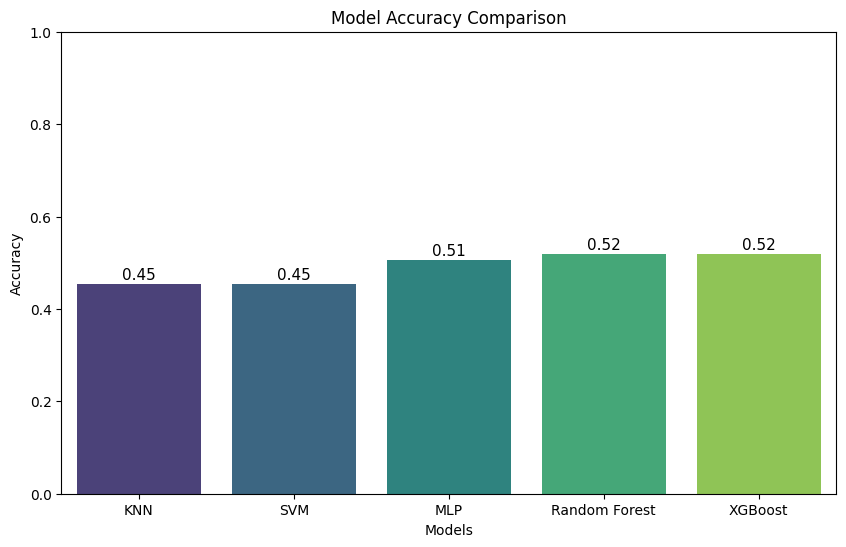

In [39]:
# ============================================
# Dynamic Model Accuracy Comparison
# ============================================

from sklearn.metrics import accuracy_score

# Calculate accuracies dynamically
knn_accuracy = accuracy_score(y_test, y_pred_knn)

svm_accuracy = accuracy_score(y_test, y_pred_svm)

mlp_accuracy = accuracy_score(y_test, y_pred_mlp)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

# --------------------------------------------
# Model names
# --------------------------------------------

models = [
    'KNN',
    'SVM',
    'MLP',
    'Random Forest',
    'XGBoost'
]

# --------------------------------------------
# Accuracy values
# --------------------------------------------

accuracies = [
    knn_accuracy,
    svm_accuracy,
    mlp_accuracy,
    rf_accuracy,
    xgb_accuracy
]

# --------------------------------------------
# Plot
# --------------------------------------------

plt.figure(figsize=(10,6))

sns.barplot(
    x=models,
    y=accuracies,
    hue=models,
    palette='viridis',
    legend=False
)

plt.title('Model Accuracy Comparison')

plt.ylabel('Accuracy')

plt.xlabel('Models')

plt.ylim(0,1)

# --------------------------------------------
# Add value labels
# --------------------------------------------

for i, acc in enumerate(accuracies):

    plt.text(
        i,
        acc + 0.01,
        f"{acc:.2f}",
        ha='center',
        fontsize=11
    )

plt.show()

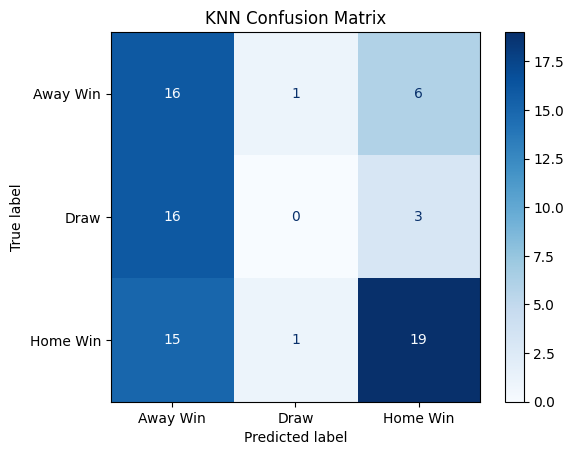

In [40]:
# ============================================
# Confusion Matrix — KNN
# ============================================

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_knn,
    display_labels=result_encoder.classes_,
    cmap='Blues'
)

plt.title('KNN Confusion Matrix')

plt.show()

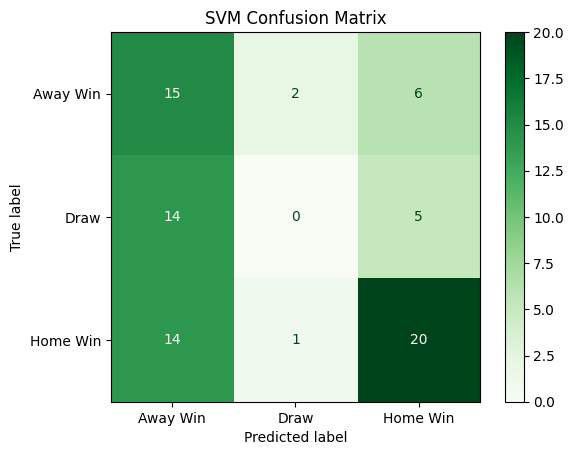

In [41]:
# ============================================
# Confusion Matrix — SVM
# ============================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    display_labels=result_encoder.classes_,
    cmap='Greens'
)

plt.title('SVM Confusion Matrix')

plt.show()

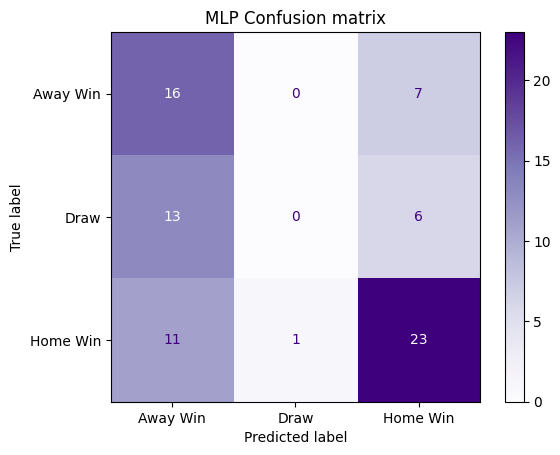

In [42]:
# ============================================
# Confusion Matrix — MLP
# ============================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_mlp,
    display_labels=result_encoder.classes_,
    cmap='Purples'
)

plt.title('MLP Confusion matrix')

plt.show()

<Figure size 600x500 with 0 Axes>

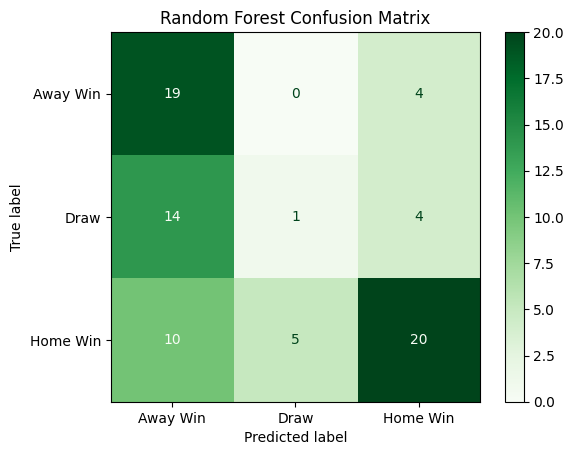

In [43]:
# ============================================
# RANDOM FOREST CONFUSION MATRIX
# ============================================

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# Random Forest Confusion Matrix
rf_cm = confusion_matrix(
    y_test,
    y_pred_rf
)

# Plot
plt.figure(figsize=(6,5))

rf_display = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=result_encoder.classes_
)

rf_display.plot(
    cmap='Greens',
    values_format='d'
)

plt.title('Random Forest Confusion Matrix')

plt.show()

<Figure size 600x500 with 0 Axes>

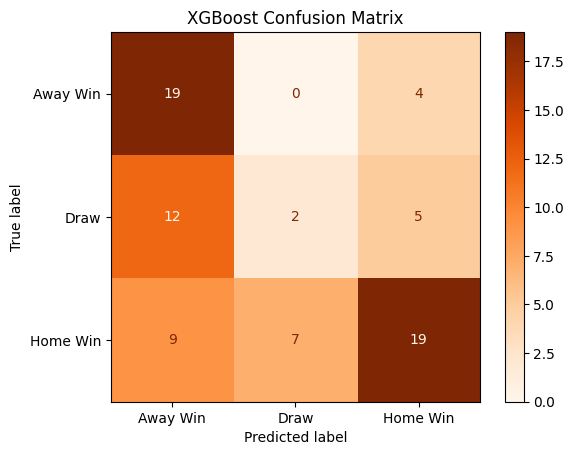

In [44]:
# ============================================
# XGBOOST CONFUSION MATRIX
# ============================================

# XGBoost Confusion Matrix
xgb_cm = confusion_matrix(
    y_test,
    y_pred_xgb
)

# Plot
plt.figure(figsize=(6,5))

xgb_display = ConfusionMatrixDisplay(
    confusion_matrix=xgb_cm,
    display_labels=result_encoder.classes_
)

xgb_display.plot(
    cmap='Oranges',
    values_format='d'
)

plt.title('XGBoost Confusion Matrix')

plt.show()

# **FIFA World Cup  Match Prediction System 🎲🏆**

In [45]:
# ============================================
# FIFA Match Prediction System
# ============================================

import numpy as np
import pandas as pd

# ============================================
# CREATE MATCH FEATURES
# ============================================

def create_match_features(home_team, away_team):

    # ----------------------------------------
    # Team Validation
    # ----------------------------------------

    available_teams = df['home_team'].unique()

    if home_team not in available_teams:
        print("Invalid Home Team")
        return None

    if away_team not in available_teams:
        print("Invalid Away Team")
        return None

    if home_team == away_team:
        print("Teams must be different.")
        return None

    # ----------------------------------------
    # Encode Teams
    # ----------------------------------------

    home_encoded = team_encoder.transform(
        [home_team]
    )[0]

    away_encoded = team_encoder.transform(
        [away_team]
    )[0]

    # ----------------------------------------
    # Modern Football Era
    # ----------------------------------------

    recent_home = df[
        (df['home_team'] == home_team)
        & (df['Year'] >= 2002)
    ]

    recent_away = df[
        (df['away_team'] == away_team)
        & (df['Year'] >= 2002)
    ]

    # ----------------------------------------
    # xG Features
    # ----------------------------------------

    home_xg = recent_home[
        'home_xg'
    ].mean()

    away_xg = recent_away[
        'away_xg'
    ].mean()

    # ----------------------------------------
    # Goal Features
    # ----------------------------------------

    home_avg_goals = recent_home[
        'home_avg_goals'
    ].mean()

    away_avg_goals = recent_away[
        'away_avg_goals'
    ].mean()

    # ----------------------------------------
    # Defensive Features
    # ----------------------------------------

    home_avg_conceded = recent_home[
        'home_avg_conceded'
    ].mean()

    away_avg_conceded = recent_away[
        'away_avg_conceded'
    ].mean()

    # ----------------------------------------
    # Replace Missing Values
    # ----------------------------------------

    if pd.isna(home_xg):
        home_xg = df['home_xg'].mean()

    if pd.isna(away_xg):
        away_xg = df['away_xg'].mean()

    if pd.isna(home_avg_goals):
        home_avg_goals = df[
            'home_avg_goals'
        ].mean()

    if pd.isna(away_avg_goals):
        away_avg_goals = df[
            'away_avg_goals'
        ].mean()

    if pd.isna(home_avg_conceded):
        home_avg_conceded = df[
            'home_avg_conceded'
        ].mean()

    if pd.isna(away_avg_conceded):
        away_avg_conceded = df[
            'away_avg_conceded'
        ].mean()

    # ----------------------------------------
    # Statistical Difference Features
    # ----------------------------------------

    goal_strength_diff = (
        home_avg_goals
        - away_avg_goals
    )

    defense_strength_diff = (
        away_avg_conceded
        - home_avg_conceded
    )

    # ----------------------------------------
    # Team Strength Ratings
    # ----------------------------------------

    home_strength = team_strength.get(
        home_team,
        75
    )

    away_strength = team_strength.get(
        away_team,
        75
    )

    strength_difference = (
        home_strength
        - away_strength
    )

    # ----------------------------------------
    # Current Year
    # ----------------------------------------

    current_year = 2026

    # ----------------------------------------
    # Create Feature DataFrame
    # ----------------------------------------

    features = pd.DataFrame([[
        home_encoded,
        away_encoded,

        home_xg,
        away_xg,

        home_avg_goals,
        away_avg_goals,

        home_avg_conceded,
        away_avg_conceded,

        goal_strength_diff,
        defense_strength_diff,

        current_year,

        strength_difference

    ]],

    columns=X.columns)

    return features


# ============================================
# PREDICT MATCH
# ============================================

def predict_match(home_team, away_team):

    # ----------------------------------------
    # Generate Features
    # ----------------------------------------

    match_features = create_match_features(
        home_team,
        away_team
    )

    if match_features is None:
        return

    # ----------------------------------------
    # Strength Difference
    # ----------------------------------------

    strength_difference = (
        team_strength.get(home_team, 75)
        - team_strength.get(away_team, 75)
    )

    # ----------------------------------------
    # Scale Features
    # ----------------------------------------

    match_scaled = scaler.transform(
        match_features
    )

    # ----------------------------------------
    # XGBOOST PROBABILITIES
    # ----------------------------------------

    probabilities = grid_xgb.predict_proba(
        match_scaled
    )[0]

    # ----------------------------------------
    # Probability Calibration
    # ----------------------------------------

    probabilities = probabilities ** 1.2

    probabilities = (
        probabilities
        / probabilities.sum()
    )

    # ----------------------------------------
    # Strong Team Bias
    # ----------------------------------------

    if strength_difference > 15:

        probabilities[2] *= 2.5
        probabilities[1] *= 0.35
        probabilities[0] *= 0.25

    elif strength_difference > 8:

        probabilities[2] *= 1.8
        probabilities[1] *= 0.55
        probabilities[0] *= 0.45

    probabilities = (
        probabilities
        / probabilities.sum()
    )

    # ----------------------------------------
    # Minimum Draw Probability
    # ----------------------------------------

    min_draw = 0.03

    if probabilities[1] < min_draw:

        remaining = 1 - min_draw

        total_non_draw = (
            probabilities[0]
            + probabilities[2]
        )

        probabilities[0] = (
            probabilities[0]
            * remaining
            / total_non_draw
        )

        probabilities[2] = (
            probabilities[2]
            * remaining
            / total_non_draw
        )

        probabilities[1] = min_draw

    # ----------------------------------------
    # Normalize Again
    # ----------------------------------------

    probabilities = (
        probabilities
        / probabilities.sum()
    )

    # ----------------------------------------
    # Labels
    # ----------------------------------------

    labels = result_encoder.classes_

    # ----------------------------------------
    # Sort Probabilities
    # ----------------------------------------

    sorted_probs = sorted(

        zip(labels, probabilities),

        key=lambda x: x[1],

        reverse=True

    )

    # ----------------------------------------
    # Display Results
    # ----------------------------------------

    print(f"\n{home_team} vs {away_team}\n")

    for label, prob in sorted_probs:

        print(
            f"{label}: {prob*100:.2f}%"
        )

    # ----------------------------------------
    # Final Prediction
    # ----------------------------------------

    prediction = max(

        sorted_probs,

        key=lambda x: x[1]

    )[0]

    print(
        f"\nPredicted Result: {prediction}"
    )


# ============================================
# INTERACTIVE PREDICTION
# ============================================

print("\nAvailable Teams:\n")

print(
    sorted(
        df['home_team'].unique()
    )
)

print("\n-----------------------------------")

home_team = input(
    "\nEnter Home Team: "
)

away_team = input(
    "Enter Away Team: "
)

predict_match(
    home_team,
    away_team
)


Available Teams:

['Algeria', 'Angola', 'Argentina', 'Australia', 'Belgium', 'Bosnia and Herzegovina', 'Brazil', 'Cameroon', 'Canada', 'Chile', 'China PR', 'Colombia', 'Costa Rica', 'Croatia', 'Czech Republic', "Côte d'Ivoire", 'Denmark', 'Ecuador', 'Egypt', 'England', 'France', 'Germany', 'Ghana', 'Greece', 'Honduras', 'IR Iran', 'Iceland', 'Italy', 'Japan', 'Korea DPR', 'Korea Republic', 'Mexico', 'Morocco', 'Netherlands', 'New Zealand', 'Nigeria', 'Panama', 'Paraguay', 'Peru', 'Poland', 'Portugal', 'Qatar', 'Republic of Ireland', 'Russia', 'Saudi Arabia', 'Senegal', 'Serbia', 'Serbia and Montenegro', 'Slovakia', 'Slovenia', 'South Africa', 'Spain', 'Sweden', 'Switzerland', 'Togo', 'Trinidad and Tobago', 'Tunisia', 'Türkiye', 'Ukraine', 'United States', 'Uruguay', 'Wales']

-----------------------------------

Enter Home Team: Argentina
Enter Away Team: Angola

Argentina vs Angola

Home Win: 77.00%
Draw: 22.38%
Away Win: 0.62%

Predicted Result: Home Win


#  FIFA World Cup 2026 Tournament Engine 🌍🏆

In [46]:
# ============================================
# MONTE CARLO PREPARATION
# ============================================

import random

# ============================================
# SAFE TEAM ENCODER
# ============================================

team_to_id = {
    team: idx
    for idx, team in enumerate(team_encoder.classes_)
}

average_team_id = int(
    np.mean(list(team_to_id.values()))
)

def safe_encode_team(team_name):

    if team_name in team_to_id:
        return team_to_id[team_name]

    return average_team_id


# ============================================
# MATCH FEATURE BUILDER
# ============================================

def build_match_features(home_team, away_team):

    home_encoded = safe_encode_team(home_team)
    away_encoded = safe_encode_team(away_team)

    home_strength = team_strength.get(home_team, 75)
    away_strength = team_strength.get(away_team, 75)

    strength_difference = (
        home_strength - away_strength
    )

    home_avg_goals = 1.5 + (
        (home_strength - 75) * 0.03
    )

    away_avg_goals = 1.5 + (
        (away_strength - 75) * 0.03
    )

    home_avg_conceded = max(
        0.5,
        1.8 - (
            (home_strength - 75) * 0.02
        )
    )

    away_avg_conceded = max(
        0.5,
        1.8 - (
            (away_strength - 75) * 0.02
        )
    )

    home_xg = (
        home_avg_goals * 0.7
        + strength_difference * 0.01
    )

    away_xg = (
        away_avg_goals * 0.7
        - strength_difference * 0.01
    )

    goal_strength_diff = (
        home_avg_goals
        - away_avg_goals
    )

    defense_strength_diff = (
        away_avg_conceded
        - home_avg_conceded
    )

    features = pd.DataFrame([[
        home_encoded,
        away_encoded,
        home_xg,
        away_xg,
        home_avg_goals,
        away_avg_goals,
        home_avg_conceded,
        away_avg_conceded,
        goal_strength_diff,
        defense_strength_diff,
        2026,
        strength_difference
    ]], columns=X.columns)

    return scaler.transform(features)


# ============================================
# MATCH PREDICTION
# ============================================
def predict_match(home_team, away_team):

    features = build_match_features(
        home_team,
        away_team
    )

    probabilities = grid_xgb.predict_proba(
        features
    )[0]

    # ============================================
    # BLEND MODEL + FOOTBALL RANDOMNESS
    # ============================================

    random_probs = np.array([
        0.35,  # Away Win
        0.25,  # Draw
        0.40   # Home Win
    ])

    probabilities = (
        0.90 * probabilities
        + 0.10 * random_probs
    )

    probabilities = (
        probabilities
        / probabilities.sum()
    )

    result = np.random.choice(
        result_encoder.classes_,
        p=probabilities
    )

    return result, probabilities

# ============================================
# REALISTIC SCORE SIMULATION
# ============================================

def simulate_score(home_team, away_team):

    home_strength = team_strength.get(
        home_team,
        75
    )

    away_strength = team_strength.get(
        away_team,
        75
    )

    strength_gap = (
        home_strength
        - away_strength
    )

    # ============================================
    # LOWER BASE GOALS
    # ============================================

    home_lambda = (
        1.1
        + (strength_gap * 0.012)
    )

    away_lambda = (
        1.0
        - (strength_gap * 0.012)
    )

    # ============================================
    # LIMIT EXTREMES
    # ============================================

    home_lambda = np.clip(
        home_lambda,
        0.4,
        2.5
    )

    away_lambda = np.clip(
        away_lambda,
        0.3,
        2.2
    )

    # ============================================
    # GENERATE GOALS
    # ============================================

    home_goals = np.random.poisson(
        home_lambda
    )

    away_goals = np.random.poisson(
        away_lambda
    )

    # ============================================
    # REDUCE CRAZY SCORES
    # ============================================

    home_goals = min(home_goals, 5)
    away_goals = min(away_goals, 5)

    return home_goals, away_goals


# ============================================
# FULL MATCH SIMULATION
# ============================================

def simulate_match(home_team, away_team):

    result, probabilities = predict_match(
        home_team,
        away_team
    )

    home_goals, away_goals = simulate_score(
        home_team,
        away_team
    )

    # Small upset chance
    if np.random.random() < 0.08:

        if result == "Home Win":
            result = "Away Win"

        elif result == "Away Win":
            result = "Home Win"

    # Force score consistency
    if result == "Home Win":

        while home_goals <= away_goals:
            home_goals += 1

    elif result == "Away Win":

        while away_goals <= home_goals:
            away_goals += 1

    else:

        away_goals = home_goals

    return {
        "home_team": home_team,
        "away_team": away_team,
        "home_goals": home_goals,
        "away_goals": away_goals,
        "result": result,
        "probabilities": probabilities
    }

In [47]:
# ============================================
# TEST MATCH SIMULATION
# ============================================

match = simulate_match(
    "Argentina",
    "France"
)

print(match)

{'home_team': 'Argentina', 'away_team': 'France', 'home_goals': 0, 'away_goals': 1, 'result': 'Away Win', 'probabilities': array([0.90685667, 0.02802246, 0.06512087])}


In [48]:
# ============================================
# MULTIPLE MATCH TEST
# ============================================

for i in range(10):

    match = simulate_match(
        "Brazil",
        "England"
    )

    print(
        f"{match['home_team']} "
        f"{match['home_goals']} - "
        f"{match['away_goals']} "
        f"{match['away_team']} "
        f"({match['result']})"
    )

Brazil 0 - 1 England (Away Win)
Brazil 2 - 1 England (Home Win)
Brazil 0 - 1 England (Away Win)
Brazil 1 - 0 England (Home Win)
Brazil 0 - 1 England (Away Win)
Brazil 1 - 2 England (Away Win)
Brazil 5 - 6 England (Away Win)
Brazil 1 - 2 England (Away Win)
Brazil 0 - 1 England (Away Win)
Brazil 0 - 0 England (Draw)


In [49]:
# ============================================
# 100 MATCH TEST
# ============================================

results = {
    "Home Win": 0,
    "Draw": 0,
    "Away Win": 0
}

for i in range(100):

    match = simulate_match(
        "Argentina",
        "France"
    )

    results[match["result"]] += 1

print(results)

{'Home Win': 16, 'Draw': 2, 'Away Win': 82}


In [50]:
# ============================================
# FIFA WORLD CUP 2026 GROUPS
# ============================================

groups = {

    "Group A": [
        "Mexico",
        "Korea Republic",
        "South Africa",
        "Czech Republic"
    ],

    "Group B": [
        "Canada",
        "Switzerland",
        "Qatar",
        "Bosnia and Herzegovina"
    ],

    "Group C": [
        "Brazil",
        "Morocco",
        "Haiti",
        "Scotland"
    ],

    "Group D": [
        "United States",
        "Paraguay",
        "Australia",
        "Türkiye"
    ],

    "Group E": [
        "Germany",
        "Ecuador",
        "Côte d'Ivoire",
        "Curacao"
    ],

    "Group F": [
        "Netherlands",
        "Japan",
        "Sweden",
        "Tunisia"
    ],

    "Group G": [
        "Belgium",
        "IR Iran",
        "Egypt",
        "New Zealand"
    ],

    "Group H": [
        "Spain",
        "Uruguay",
        "Saudi Arabia",
        "Cape Verde"
    ],

    "Group I": [
        "France",
        "Senegal",
        "Norway",
        "Iraq"
    ],

    "Group J": [
        "Argentina",
        "Algeria",
        "Austria",
        "Jordan"
    ],

    "Group K": [
        "Portugal",
        "Colombia",
        "Uzbekistan",
        "DR Congo"
    ],

    "Group L": [
        "England",
        "Croatia",
        "Ghana",
        "Panama"
    ]
}

In [51]:
# ============================================
# GROUP STAGE TABLE
# ============================================

def simulate_group(group_name, teams):

    print(f"\n{group_name}")
    print("-" * 40)

    standings = {

        team: {

            "points": 0,
            "wins": 0,
            "draws": 0,
            "losses": 0,
            "goals_for": 0,
            "goals_against": 0,
            "goal_difference": 0

        }

        for team in teams
    }

    # ============================================
    # ROUND ROBIN MATCHES
    # ============================================

    for i in range(len(teams)):

        for j in range(i + 1, len(teams)):

            home = teams[i]
            away = teams[j]

            match = simulate_match(
                home,
                away
            )

            home_goals = match["home_goals"]
            away_goals = match["away_goals"]

            print(
                f"{home} "
                f"{home_goals} - "
                f"{away_goals} "
                f"{away}"
            )

            # ============================================
            # UPDATE GOALS
            # ============================================

            standings[home]["goals_for"] += home_goals
            standings[home]["goals_against"] += away_goals

            standings[away]["goals_for"] += away_goals
            standings[away]["goals_against"] += home_goals

            # ============================================
            # HOME WIN
            # ============================================

            if home_goals > away_goals:

                standings[home]["points"] += 3
                standings[home]["wins"] += 1

                standings[away]["losses"] += 1

            # ============================================
            # AWAY WIN
            # ============================================

            elif away_goals > home_goals:

                standings[away]["points"] += 3
                standings[away]["wins"] += 1

                standings[home]["losses"] += 1

            # ============================================
            # DRAW
            # ============================================

            else:

                standings[home]["points"] += 1
                standings[away]["points"] += 1

                standings[home]["draws"] += 1
                standings[away]["draws"] += 1

    # ============================================
    # GOAL DIFFERENCE
    # ============================================

    for team in teams:

        standings[team]["goal_difference"] = (

            standings[team]["goals_for"]
            - standings[team]["goals_against"]

        )

    # ============================================
    # SORT TABLE
    # ============================================

    sorted_table = sorted(

        standings.items(),

        key=lambda x: (

            x[1]["points"],
            x[1]["goal_difference"],
            x[1]["goals_for"]

        ),

        reverse=True
    )

    # ============================================
    # DISPLAY TABLE
    # ============================================

    print("\nFINAL STANDINGS:\n")

    for position, (team, stats) in enumerate(
        sorted_table,
        start=1
    ):

        print(
            f"{position}. "
            f"{team} | "
            f"{stats['points']} pts | "
            f"GD: {stats['goal_difference']}"
        )

    return sorted_table

In [52]:
# ============================================
# TEST GROUP SIMULATION
# ============================================

simulate_group(
    "Group A",
    groups["Group A"]
)


Group A
----------------------------------------
Mexico 1 - 0 Korea Republic
Mexico 1 - 0 South Africa
Mexico 2 - 1 Czech Republic
Korea Republic 1 - 2 South Africa
Korea Republic 2 - 1 Czech Republic
South Africa 0 - 0 Czech Republic

FINAL STANDINGS:

1. Mexico | 9 pts | GD: 3
2. South Africa | 4 pts | GD: 0
3. Korea Republic | 3 pts | GD: -1
4. Czech Republic | 1 pts | GD: -2


[('Mexico',
  {'points': 9,
   'wins': 3,
   'draws': 0,
   'losses': 0,
   'goals_for': 4,
   'goals_against': 1,
   'goal_difference': 3}),
 ('South Africa',
  {'points': 4,
   'wins': 1,
   'draws': 1,
   'losses': 1,
   'goals_for': 2,
   'goals_against': 2,
   'goal_difference': 0}),
 ('Korea Republic',
  {'points': 3,
   'wins': 1,
   'draws': 0,
   'losses': 2,
   'goals_for': 3,
   'goals_against': 4,
   'goal_difference': -1}),
 ('Czech Republic',
  {'points': 1,
   'wins': 0,
   'draws': 1,
   'losses': 2,
   'goals_for': 2,
   'goals_against': 4,
   'goal_difference': -2})]

In [53]:
# ============================================
# SIMULATE ALL GROUPS
# ============================================

group_winners = []

group_runners_up = []

third_place_teams = []

# ============================================
# SIMULATE GROUPS
# ============================================

for group_name, teams in groups.items():

    table = simulate_group(
        group_name,
        teams
    )

    # ============================================
    # TOP 2 TEAMS
    # ============================================

    winner = table[0]
    runner_up = table[1]
    third_place = table[2]

    # Store winners
    group_winners.append(
        winner[0]
    )

    # Store runners-up
    group_runners_up.append(
        runner_up[0]
    )

    # ============================================
    # STORE THIRD-PLACE TEAM
    # ============================================

    third_place_teams.append({

        "team": third_place[0],

        "points": third_place[1]["points"],

        "goal_difference":

        third_place[1][
            "goal_difference"
        ],

        "goals_for":

        third_place[1][
            "goals_for"
        ]
    })

# ============================================
# SORT THIRD-PLACE TEAMS
# ============================================

third_place_teams = sorted(

    third_place_teams,

    key=lambda x: (

        x["points"],

        x["goal_difference"],

        x["goals_for"]

    ),

    reverse=True
)

# ============================================
# BEST 8 THIRD-PLACE TEAMS
# ============================================

best_third_place = third_place_teams[:8]

# ============================================
# DISPLAY QUALIFIED TEAMS
# ============================================

print("\n===================================")
print("ROUND OF 32 QUALIFIERS")
print("===================================\n")

# Winners
print("GROUP WINNERS:\n")

for team in group_winners:

    print(team)

# Runners-up
print("\nRUNNERS-UP:\n")

for team in group_runners_up:

    print(team)

# Best third-place teams
print("\nBEST THIRD-PLACE TEAMS:\n")

for team in best_third_place:

    print(

        f"{team['team']} "

        f"({team['points']} pts)"

    )

# ============================================
# FINAL ROUND OF 32 TEAMS
# ============================================

qualified_teams = (

    group_winners
    + group_runners_up
    + [

        team["team"]

        for team in best_third_place
    ]
)

# ============================================
# DISPLAY FINAL LIST
# ============================================

print("\n===================================")
print("FINAL ROUND OF 32")
print("===================================\n")

for team in qualified_teams:

    print(team)


Group A
----------------------------------------
Mexico 3 - 2 Korea Republic
Mexico 2 - 1 South Africa
Mexico 1 - 0 Czech Republic
Korea Republic 1 - 2 South Africa
Korea Republic 2 - 3 Czech Republic
South Africa 2 - 1 Czech Republic

FINAL STANDINGS:

1. Mexico | 9 pts | GD: 3
2. South Africa | 6 pts | GD: 1
3. Czech Republic | 3 pts | GD: -1
4. Korea Republic | 0 pts | GD: -3

Group B
----------------------------------------
Canada 0 - 2 Switzerland
Canada 3 - 2 Qatar
Canada 2 - 2 Bosnia and Herzegovina
Switzerland 3 - 2 Qatar
Switzerland 2 - 1 Bosnia and Herzegovina
Qatar 0 - 0 Bosnia and Herzegovina

FINAL STANDINGS:

1. Switzerland | 9 pts | GD: 4
2. Canada | 4 pts | GD: -1
3. Bosnia and Herzegovina | 2 pts | GD: -1
4. Qatar | 1 pts | GD: -2

Group C
----------------------------------------
Brazil 2 - 0 Morocco
Brazil 2 - 0 Haiti
Brazil 2 - 0 Scotland
Morocco 3 - 0 Haiti
Morocco 3 - 2 Scotland
Haiti 0 - 0 Scotland

FINAL STANDINGS:

1. Brazil | 9 pts | GD: 6
2. Morocco | 6 pts |

In [54]:
# ============================================
# KNOCKOUT MATCH
# ============================================

def simulate_knockout_match(team1, team2):

    match = simulate_match(
        team1,
        team2
    )

    home_goals = match["home_goals"]
    away_goals = match["away_goals"]

    print(
        f"{team1} "
        f"{home_goals} - "
        f"{away_goals} "
        f"{team2}"
    )

    # ============================================
    # NORMAL WINNER
    # ============================================

    if home_goals > away_goals:

        return team1

    elif away_goals > home_goals:

        return team2

    # ============================================
    # PENALTY SHOOTOUT
    # ============================================

    else:

        winner = random.choice(
            [team1, team2]
        )

        print(
            f"Penalty Winner: {winner}"
        )

        return winner

In [55]:
# ============================================
# ROUND OF 32 SIMULATION
# ============================================

print("\n===================================")
print("ROUND OF 32")
print("===================================\n")

round_of_32_winners = []

# ============================================
# CREATE MATCHUPS
# ============================================

for i in range(0, len(qualified_teams), 2):

    team1 = qualified_teams[i]
    team2 = qualified_teams[i + 1]

    winner = simulate_knockout_match(
        team1,
        team2
    )

    round_of_32_winners.append(
        winner
    )

# ============================================
# DISPLAY ROUND OF 16 TEAMS
# ============================================

print("\n===================================")
print("ROUND OF 16 QUALIFIERS")
print("===================================\n")

for team in round_of_32_winners:

    print(team)


ROUND OF 32

Mexico 0 - 1 Switzerland
Brazil 2 - 1 Türkiye
Germany 1 - 2 Netherlands
Belgium 3 - 4 Spain
France 2 - 3 Argentina
Portugal 0 - 2 Croatia
South Africa 3 - 4 Canada
Morocco 3 - 2 United States
Ecuador 2 - 1 Sweden
Egypt 0 - 1 Uruguay
Norway 2 - 3 Jordan
Uzbekistan 1 - 2 England
Ghana 1 - 2 Colombia
Senegal 2 - 1 Czech Republic
Paraguay 2 - 1 Saudi Arabia
New Zealand 1 - 0 Austria

ROUND OF 16 QUALIFIERS

Switzerland
Brazil
Netherlands
Spain
Argentina
Croatia
Canada
Morocco
Ecuador
Uruguay
Jordan
England
Colombia
Senegal
Paraguay
New Zealand


In [56]:
# ============================================
# ROUND OF 16 SIMULATION
# ============================================

print("\n===================================")
print("ROUND OF 16")
print("===================================\n")

round_of_16_winners = []

# ============================================
# CREATE MATCHUPS
# ============================================

for i in range(0, len(round_of_32_winners), 2):

    team1 = round_of_32_winners[i]
    team2 = round_of_32_winners[i + 1]

    winner = simulate_knockout_match(
        team1,
        team2
    )

    round_of_16_winners.append(
        winner
    )

# ============================================
# DISPLAY QUARTERFINALISTS
# ============================================

print("\n===================================")
print("QUARTERFINALISTS")
print("===================================\n")

for team in round_of_16_winners:

    print(team)


ROUND OF 16

Switzerland 0 - 0 Brazil
Penalty Winner: Switzerland
Netherlands 3 - 3 Spain
Penalty Winner: Netherlands
Argentina 2 - 0 Croatia
Canada 1 - 2 Morocco
Ecuador 2 - 1 Uruguay
Jordan 1 - 2 England
Colombia 0 - 0 Senegal
Penalty Winner: Senegal
Paraguay 2 - 1 New Zealand

QUARTERFINALISTS

Switzerland
Netherlands
Argentina
Morocco
Ecuador
England
Senegal
Paraguay


In [57]:
# ============================================
# QUARTERFINALS
# ============================================

print("\n===================================")
print("QUARTERFINALS")
print("===================================\n")

quarterfinal_winners = []

# ============================================
# CREATE MATCHUPS
# ============================================

for i in range(0, len(round_of_16_winners), 2):

    team1 = round_of_16_winners[i]
    team2 = round_of_16_winners[i + 1]

    winner = simulate_knockout_match(
        team1,
        team2
    )

    quarterfinal_winners.append(
        winner
    )

# ============================================
# DISPLAY SEMIFINALISTS
# ============================================

print("\n===================================")
print("SEMIFINALISTS")
print("===================================\n")

for team in quarterfinal_winners:

    print(team)


QUARTERFINALS

Switzerland 0 - 1 Netherlands
Argentina 1 - 2 Morocco
Ecuador 1 - 2 England
Senegal 2 - 3 Paraguay

SEMIFINALISTS

Netherlands
Morocco
England
Paraguay


In [58]:
# ============================================
# SEMIFINALS
# ============================================

print("\n===================================")
print("SEMIFINALS")
print("===================================\n")

semifinal_winners = []

# ============================================
# CREATE MATCHUPS
# ============================================

for i in range(0, len(quarterfinal_winners), 2):

    team1 = quarterfinal_winners[i]
    team2 = quarterfinal_winners[i + 1]

    winner = simulate_knockout_match(
        team1,
        team2
    )

    semifinal_winners.append(
        winner
    )

# ============================================
# DISPLAY FINALISTS
# ============================================

print("\n===================================")
print("FINALISTS")
print("===================================\n")

for team in semifinal_winners:

    print(team)


SEMIFINALS

Netherlands 3 - 1 Morocco
England 2 - 1 Paraguay

FINALISTS

Netherlands
England


In [59]:
# ============================================
# THIRD PLACE MATCH
# ============================================

print("\n===================================")
print("THIRD PLACE MATCH")
print("===================================\n")

# Teams that lost in semifinals
third_place_teams = []

for team in quarterfinal_winners:

    if team not in semifinal_winners:

        third_place_teams.append(team)

third_place_winner = simulate_knockout_match(

    third_place_teams[0],
    third_place_teams[1]
)

print("\n===================================")
print(f"THIRD PLACE: {third_place_winner}")
print("===================================")


THIRD PLACE MATCH

Morocco 0 - 1 Paraguay

THIRD PLACE: Paraguay


In [60]:
# ============================================
# FINAL
# ============================================

print("\n===================================")
print("FINAL")
print("===================================\n")

champion = simulate_knockout_match(

    semifinal_winners[0],
    semifinal_winners[1]
)

# ============================================
# WORLD CUP CHAMPION
# ============================================

print("\n===================================")
print(f"WORLD CUP CHAMPION: {champion}")
print("===================================")


FINAL

Netherlands 1 - 2 England

WORLD CUP CHAMPION: England


# Monte Carlo World Cup Simulation 🎲🏆

In [61]:
# ============================================
#Importing Libarires
# ============================================

import random
import numpy as np
import pandas as pd



# ============================================
# TOURNAMENT STATISTICS
# ============================================

tournament_stats = {

    "total_goals": 0,

    "matches_played": 0,

    "highest_scoring_match": {

        "match": "",
        "goals": 0
    },

    "biggest_upset": {

        "match": "",
        "strength_gap": 0
    },

    "clean_sheets": {},

    "team_goals": {}
}

# ============================================
# SILENT KNOCKOUT MATCH
# ============================================

def simulate_knockout_match(team1, team2):

    match = simulate_match(
        team1,
        team2
    )

    home_goals = match["home_goals"]
    away_goals = match["away_goals"]

    if home_goals > away_goals:

        return team1

    elif away_goals > home_goals:

        return team2

    else:

        winner = random.choice(
            [team1, team2]
        )

        return winner


# ============================================
# SILENT GROUP SIMULATION
# ============================================

def simulate_group(group_name, teams):

    standings = {}

    for team in teams:

        standings[team] = {

            "points": 0,
            "wins": 0,
            "draws": 0,
            "losses": 0,
            "goals_for": 0,
            "goals_against": 0,
            "goal_difference": 0
        }

    matches = []

    for i in range(len(teams)):

        for j in range(i + 1, len(teams)):

            matches.append(
                (teams[i], teams[j])
            )

    for home_team, away_team in matches:

        result = simulate_match(
            home_team,
            away_team
        )

        home_goals = result["home_goals"]
        away_goals = result["away_goals"]

        # ============================================
        # TOURNAMENT STATISTICS
        # ============================================

        total_match_goals = (
            home_goals + away_goals
        )

        tournament_stats["total_goals"] += (
            total_match_goals
        )

        tournament_stats["matches_played"] += 1

        # ============================================
        # TEAM GOALS
        # ============================================

        if home_team not in tournament_stats["team_goals"]:

            tournament_stats["team_goals"][home_team] = 0

        if away_team not in tournament_stats["team_goals"]:

            tournament_stats["team_goals"][away_team] = 0

        tournament_stats["team_goals"][home_team] += (
            home_goals
        )

        tournament_stats["team_goals"][away_team] += (
            away_goals
        )

        # ============================================
        # CLEAN SHEETS
        # ============================================

        if home_team not in tournament_stats["clean_sheets"]:

            tournament_stats["clean_sheets"][home_team] = 0

        if away_team not in tournament_stats["clean_sheets"]:

            tournament_stats["clean_sheets"][away_team] = 0

        if away_goals == 0:

            tournament_stats["clean_sheets"][home_team] += 1

        if home_goals == 0:

            tournament_stats["clean_sheets"][away_team] += 1

        # ============================================
        # HIGHEST SCORING MATCH
        # ============================================

        if total_match_goals > tournament_stats[
            "highest_scoring_match"
        ]["goals"]:

            tournament_stats[
                "highest_scoring_match"
            ] = {

                "match":
                f"{home_team} "
                f"{home_goals}-{away_goals} "
                f"{away_team}",

                "goals":
                total_match_goals
            }

        # ============================================
        # BIGGEST UPSET
        # ============================================

        home_strength = team_strength.get(
            home_team,
            75
        )

        away_strength = team_strength.get(
            away_team,
            75
        )

        strength_gap = abs(
            home_strength - away_strength
        )

        underdog_win = (

            (home_strength < away_strength
             and home_goals > away_goals)

            or

            (away_strength < home_strength
             and away_goals > home_goals)
        )

        if underdog_win:

            if strength_gap > tournament_stats[
                "biggest_upset"
            ]["strength_gap"]:

                tournament_stats[
                    "biggest_upset"
                ] = {

                    "match":
                    f"{home_team} "
                    f"{home_goals}-{away_goals} "
                    f"{away_team}",

                    "strength_gap":
                    strength_gap
                }

        # ============================================
        # STANDINGS UPDATE
        # ============================================

        standings[home_team]["goals_for"] += home_goals
        standings[home_team]["goals_against"] += away_goals

        standings[away_team]["goals_for"] += away_goals
        standings[away_team]["goals_against"] += home_goals

        standings[home_team]["goal_difference"] = (
            standings[home_team]["goals_for"]
            - standings[home_team]["goals_against"]
        )

        standings[away_team]["goal_difference"] = (
            standings[away_team]["goals_for"]
            - standings[away_team]["goals_against"]
        )

        if home_goals > away_goals:

            standings[home_team]["points"] += 3
            standings[home_team]["wins"] += 1

            standings[away_team]["losses"] += 1

        elif away_goals > home_goals:

            standings[away_team]["points"] += 3
            standings[away_team]["wins"] += 1

            standings[home_team]["losses"] += 1

        else:

            standings[home_team]["points"] += 1
            standings[away_team]["points"] += 1

            standings[home_team]["draws"] += 1
            standings[away_team]["draws"] += 1

    sorted_table = sorted(

        standings.items(),

        key=lambda x: (

            x[1]["points"],
            x[1]["goal_difference"],
            x[1]["goals_for"]

        ),

        reverse=True
    )

    return sorted_table

In [62]:
# ============================================
# TOURNAMENT FUNCTION
# ============================================

def simulate_tournament():

    group_winners = []
    group_runners_up = []
    third_place_teams = []

    # ============================================
    # GROUP STAGE
    # ============================================

    for group_name, teams in groups.items():

        table = simulate_group(
            group_name,
            teams
        )

        winner = table[0]
        runner_up = table[1]
        third_place = table[2]

        group_winners.append(
            winner[0]
        )

        group_runners_up.append(
            runner_up[0]
        )

        third_place_teams.append({

            "team": third_place[0],

            "points":
            third_place[1]["points"],

            "goal_difference":
            third_place[1][
                "goal_difference"
            ],

            "goals_for":
            third_place[1][
                "goals_for"
            ]
        })

    # ============================================
    # BEST THIRD-PLACE TEAMS
    # ============================================

    third_place_teams = sorted(

        third_place_teams,

        key=lambda x: (

            x["points"],
            x["goal_difference"],
            x["goals_for"]

        ),

        reverse=True
    )

    best_third_place = (
        third_place_teams[:8]
    )

    qualified_teams = (

        group_winners
        + group_runners_up
        + [

            team["team"]

            for team in best_third_place
        ]
    )

    # ============================================
    # ROUND OF 32
    # ============================================

    round_of_32_winners = []

    for i in range(
        0,
        len(qualified_teams),
        2
    ):

        winner = simulate_knockout_match(

            qualified_teams[i],
            qualified_teams[i + 1]
        )

        round_of_32_winners.append(
            winner
        )

    # ============================================
    # ROUND OF 16
    # ============================================

    round_of_16_winners = []

    for i in range(
        0,
        len(round_of_32_winners),
        2
    ):

        winner = simulate_knockout_match(

            round_of_32_winners[i],
            round_of_32_winners[i + 1]
        )

        round_of_16_winners.append(
            winner
        )

    # ============================================
    # QUARTERFINALS
    # ============================================

    quarterfinal_winners = []

    for i in range(
        0,
        len(round_of_16_winners),
        2
    ):

        winner = simulate_knockout_match(

            round_of_16_winners[i],
            round_of_16_winners[i + 1]
        )

        quarterfinal_winners.append(
            winner
        )

    # ============================================
    # SEMIFINALS
    # ============================================

    semifinal_winners = []

    for i in range(
        0,
        len(quarterfinal_winners),
        2
    ):

        winner = simulate_knockout_match(

            quarterfinal_winners[i],
            quarterfinal_winners[i + 1]
        )

        semifinal_winners.append(
            winner
        )

    # ============================================
    # FINAL
    # ============================================

    champion = simulate_knockout_match(

        semifinal_winners[0],
        semifinal_winners[1]
    )

    return champion


# ============================================
# MONTE CARLO SIMULATION
# ============================================

simulation_count = 300

champions = {}

# ============================================
# RUN SIMULATIONS
# ============================================

for i in range(simulation_count):

    champion = simulate_tournament()

    if champion not in champions:

        champions[champion] = 0

    champions[champion] += 1

# ============================================
# SORT RESULTS
# ============================================

champions = dict(

    sorted(

        champions.items(),

        key=lambda x: x[1],

        reverse=True
    )
)

# ============================================
# DISPLAY RESULTS
# ============================================

print("\n===================================")
print("FIFA WORLD CUP 2026 AI PREDICTION")
print("===================================\n")

print(f"Total Simulations: {simulation_count}")

print("\n===================================")
print("MONTE CARLO WORLD CUP RESULTS")
print("===================================\n")

for team, wins in champions.items():

    probability = (
        wins / simulation_count
    ) * 100

    print(

        f"{team}: "

        f"{wins} wins "

        f"({probability:.2f}%)"
    )
# ============================================
# TOURNAMENT STATISTICS REPORT
# ============================================

print("\n===================================")
print("TOURNAMENT STATISTICS")
print("===================================\n")

print(
    f"Total Goals: "
    f"{tournament_stats['total_goals']}"
)

average_goals = (

    tournament_stats["total_goals"]

    / tournament_stats["matches_played"]
)

print(
    f"Average Goals Per Match: "
    f"{average_goals:.2f}"
)

print(
    "\nHighest Scoring Match:"
)

print(
    tournament_stats[
        "highest_scoring_match"
    ]["match"]
)

print(
    "\nBiggest Upset:"
)

print(
    tournament_stats[
        "biggest_upset"
    ]["match"]
)

top_team = max(

    tournament_stats["team_goals"],

    key=tournament_stats[
        "team_goals"
    ].get
)

print(
    f"\nTop Scoring Team: "
    f"{top_team}"
)

print(
    f"Goals Scored: "
    f"{tournament_stats['team_goals'][top_team]}"
)

best_defense = max(

    tournament_stats["clean_sheets"],

    key=tournament_stats[
        "clean_sheets"
    ].get
)

print(
    f"\nMost Clean Sheets: "
    f"{best_defense}"
)

print(
    f"Clean Sheets: "
    f"{tournament_stats['clean_sheets'][best_defense]}"
)


FIFA WORLD CUP 2026 AI PREDICTION

Total Simulations: 300

MONTE CARLO WORLD CUP RESULTS

Brazil: 40 wins (13.33%)
England: 39 wins (13.00%)
Argentina: 29 wins (9.67%)
Croatia: 24 wins (8.00%)
Netherlands: 23 wins (7.67%)
Spain: 20 wins (6.67%)
Portugal: 19 wins (6.33%)
Belgium: 17 wins (5.67%)
Japan: 17 wins (5.67%)
France: 15 wins (5.00%)
Morocco: 13 wins (4.33%)
Colombia: 9 wins (3.00%)
Uruguay: 7 wins (2.33%)
Switzerland: 6 wins (2.00%)
Sweden: 6 wins (2.00%)
Mexico: 4 wins (1.33%)
Austria: 2 wins (0.67%)
Egypt: 2 wins (0.67%)
Germany: 1 wins (0.33%)
Türkiye: 1 wins (0.33%)
Senegal: 1 wins (0.33%)
Norway: 1 wins (0.33%)
Côte d'Ivoire: 1 wins (0.33%)
United States: 1 wins (0.33%)
Bosnia and Herzegovina: 1 wins (0.33%)
Ghana: 1 wins (0.33%)

TOURNAMENT STATISTICS

Total Goals: 67024
Average Goals Per Match: 3.10

Highest Scoring Match:
Brazil 5-6 Morocco

Biggest Upset:
Argentina 2-3 Algeria

Top Scoring Team: Switzerland
Goals Scored: 1879

Most Clean Sheets: Belgium
Clean Sheets: 

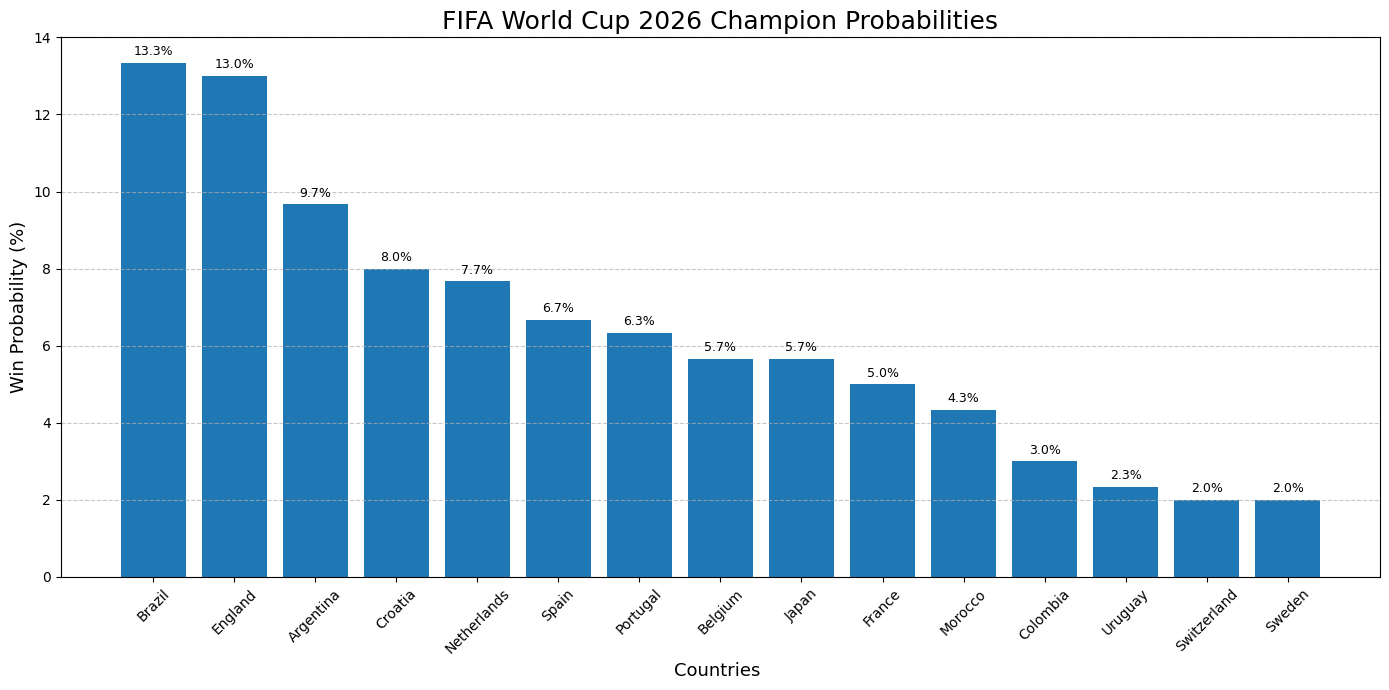

In [63]:
# ============================================
# CHAMPION PROBABILITY CHART
# ============================================

import matplotlib.pyplot as plt

# --------------------------------------------
# Sort Champion Results
# --------------------------------------------

sorted_champions = sorted(

    champions.items(),

    key=lambda x: x[1],

    reverse=True
)

# --------------------------------------------
# Extract Teams & Probabilities
# --------------------------------------------

teams = [

    team

    for team, wins

    in sorted_champions
]

probabilities = [

    (wins / simulation_count) * 100

    for team, wins

    in sorted_champions
]

# --------------------------------------------
# Show Only Top 15 Teams
# --------------------------------------------

teams = teams[:15]

probabilities = probabilities[:15]

# --------------------------------------------
# Create Figure
# --------------------------------------------

plt.figure(figsize=(14, 7))

# --------------------------------------------
# Create Bar Chart
# --------------------------------------------

bars = plt.bar(

    teams,
    probabilities
)

# --------------------------------------------
# Chart Title
# --------------------------------------------

plt.title(

    "FIFA World Cup 2026 Champion Probabilities",

    fontsize=18
)

# --------------------------------------------
# Axis Labels
# --------------------------------------------

plt.xlabel(

    "Countries ",

    fontsize=13
)

plt.ylabel(

    "Win Probability (%)",

    fontsize=13
)

# --------------------------------------------
# Rotate Team Names
# --------------------------------------------

plt.xticks(

    rotation=45
)

# --------------------------------------------
# Add Grid
# --------------------------------------------

plt.grid(

    axis='y',

    linestyle='--',

    alpha=0.7
)

# --------------------------------------------
# Add Percentage Labels
# --------------------------------------------

for i, value in enumerate(probabilities):

    plt.text(

        i,
        value + 0.2,

        f"{value:.1f}%",

        ha='center',

        fontsize=9
    )

# --------------------------------------------
# Tight Layout
# --------------------------------------------

plt.tight_layout()

# --------------------------------------------
# Show Chart
# --------------------------------------------

plt.show()

# Streamlit

In [15]:
!pip install streamlit pyngrok -q

In [44]:

%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import time

# =========================================================
# PAGE CONFIG
# =========================================================

st.set_page_config(
    page_title="FIFA World Cup 2026 AI Simulator",
    page_icon="🏆",
    layout="wide"
)

# =========================================================
# RANDOM SEED
# =========================================================

random.seed(42)
np.random.seed(42)

# =========================================================
# CUSTOM CSS
# =========================================================

st.markdown("""
<style>

.main {
    background-color: #050816;
    color: white;
}

section[data-testid="stSidebar"] {
    background-color: #111827;
}

h1, h2, h3, h4 {
    color: white;
}

.stButton>button {
    width: 100%;
    border-radius: 10px;
    height: 3em;
    font-size: 18px;
    background-color: #111827;
    color: white;
    border: 1px solid #374151;
}

.stButton>button:hover {
    background-color: #1f2937;
}

</style>
""", unsafe_allow_html=True)

# =========================================================
# SIDEBAR
# =========================================================

st.sidebar.title("📊 Project Information")

st.sidebar.markdown("""
## AI Technologies Used

- Machine Learning
- Monte Carlo Simulation
- Knockout Tournament Engine
- Statistical Match Prediction
- Tournament Analytics

---

## Model Statistics

- Best Model Accuracy: 52%
- Simulations: 300
- Teams: 48
- Tournament: FIFA World Cup 2026
- Models: KNN, SVM, MLP, RF, XGBoost

---

## Dataset

- FIFA World Cup Matches
- Years: 1930–2022
- Features:
    - xG
    - Goal Difference
    - Team Strength
    - Defensive Rating
    - Historical Performance

---

## Tournament Engine

- Dynamic Match Simulation
- Penalty Shootouts
- Knockout Bracket Logic
- Upset Probability Engine
""")

# =========================================================
# TITLE
# =========================================================

st.title("🏆 FIFA World Cup 2026 AI Tournament Simulator")

st.markdown("""
Advanced football analytics platform powered by:

- Machine Learning
- Monte Carlo Simulation
- Knockout Tournament Engine
- Tournament Analytics
""")

# =========================================================
# WORLD CUP 2026 TEAMS
# =========================================================

teams = [

    # AFC
    "Australia",
    "Iraq",
    "IR Iran",
    "Japan",
    "Jordan",
    "Korea Republic",
    "Qatar",
    "Saudi Arabia",
    "Uzbekistan",

    # CAF
    "Algeria",
    "Cabo Verde",
    "Congo DR",
    "Côte d’Ivoire",
    "Egypt",
    "Ghana",
    "Morocco",
    "Senegal",
    "South Africa",
    "Tunisia",

    # CONCACAF
    "Canada",
    "Curaçao",
    "Haiti",
    "Mexico",
    "Panama",
    "United States",

    # CONMEBOL
    "Argentina",
    "Brazil",
    "Colombia",
    "Ecuador",
    "Paraguay",
    "Uruguay",

    # OFC
    "New Zealand",

    # UEFA
    "Austria",
    "Belgium",
    "Bosnia and Herzegovina",
    "Croatia",
    "Czechia",
    "England",
    "France",
    "Germany",
    "Netherlands",
    "Norway",
    "Portugal",
    "Scotland",
    "Spain",
    "Sweden",
    "Switzerland",
    "Türkiye"
]

# =========================================================
# TEAM STRENGTHS
# =========================================================

team_strength = {

    "Argentina": 96,
    "France": 96,
    "Spain": 94,
    "Brazil": 93,
    "England": 91,
    "Portugal": 90,
    "Belgium": 88,
    "Netherlands": 85,
    "Croatia": 84,
    "Uruguay": 84,
    "Germany": 82,
    "Switzerland": 82,
    "Japan": 82,
    "Morocco": 82,
    "Colombia": 81,
    "Mexico": 80,
    "Senegal": 80,
    "Sweden": 79,
    "Austria": 78,
    "Norway": 78,
    "Türkiye": 77,
    "United States": 77,
    "Egypt": 75,
    "Canada": 75,
    "Saudi Arabia": 72,
    "Qatar": 70,
    "Australia": 74,
    "Ecuador": 78,
    "Korea Republic": 76,
    "Tunisia": 73,
    "Poland": 79,
    "Serbia": 76,
    "Jordan": 74,
    "Paraguay": 78,
    "Uzbekistan": 72,
    "Czechia": 78,
    "South Africa": 73,
    "New Zealand": 70,
    "Algeria": 79,
    "Cabo Verde": 72,
    "Congo DR": 73,
    "Côte d’Ivoire": 78,
    "Curaçao": 65,
    "Haiti": 67,
    "Iraq": 72,
    "IR Iran": 78,
    "Scotland": 79,
    "Panama": 70,
    "Bosnia and Herzegovina": 74,
    "Ghana": 75
}

# =========================================================
# MATCH PREDICTION
# =========================================================

def predict_match(team1, team2):

    strength1 = team_strength.get(team1, 75)
    strength2 = team_strength.get(team2, 75)

    diff = strength1 - strength2

    team1_prob = 50 + (diff * 1.2)
    team2_prob = 50 - (diff * 1.2)

    draw_prob = 18

    total = team1_prob + team2_prob + draw_prob

    team1_prob = (team1_prob / total) * 100
    team2_prob = (team2_prob / total) * 100
    draw_prob = (draw_prob / total) * 100

    probs = [team1_prob, draw_prob, team2_prob]

    result = np.random.choice(
        ["Home Win", "Draw", "Away Win"],
        p=np.array(probs)/100
    )

    return result, probs

# =========================================================
# SCORE SIMULATION
# =========================================================

def simulate_score(team1, team2):

    s1 = team_strength.get(team1, 75)
    s2 = team_strength.get(team2, 75)

    g1 = np.random.poisson(max(1.2, s1 / 28))
    g2 = np.random.poisson(max(1.0, s2 / 30))

    return g1, g2

# =========================================================
# MATCH ENGINE
# =========================================================

def simulate_match(team1, team2):

    result, probabilities = predict_match(team1, team2)

    home_goals, away_goals = simulate_score(team1, team2)

    if np.random.random() < 0.08:

        if result == "Home Win":
            result = "Away Win"

        elif result == "Away Win":
            result = "Home Win"

    if result == "Home Win":

        while home_goals <= away_goals:
            home_goals += 1

    elif result == "Away Win":

        while away_goals <= home_goals:
            away_goals += 1

    else:

        away_goals = home_goals

    return {
        "team1": team1,
        "team2": team2,
        "g1": home_goals,
        "g2": away_goals,
        "result": result,
        "probabilities": probabilities
    }

# =========================================================
# MATCH PREDICTOR
# =========================================================

st.divider()

st.header("⚽ AI Match Predictor")

col1, col2 = st.columns(2)

with col1:
    team1 = st.selectbox(
        "🌍 First Team",
        sorted(teams)
    )

with col2:
    team2 = st.selectbox(
        "⚽ Second Team",
        sorted(teams),
        index=1
    )

if st.button("🔮 Predict Match"):

    if team1 == team2:

        st.error("Choose two different teams.")

    else:

        result = simulate_match(team1, team2)

        st.success(
            f"{result['team1']} {result['g1']} - {result['g2']} {result['team2']}"
        )

        st.subheader("📊 Win Probabilities")

        probs_df = pd.DataFrame({

            "Outcome": [
                f"{team1} Win",
                "Draw",
                f"{team2} Win"
            ],

            "Probability (%)": [
                round(result['probabilities'][0], 1),
                round(result['probabilities'][1], 1),
                round(result['probabilities'][2], 1)
            ]
        })

        st.dataframe(
            probs_df,
            use_container_width=True
        )

# =========================================================
# MONTE CARLO SECTION
# =========================================================

st.divider()

st.header("🎲 Monte Carlo World Cup Simulation")

champion_probs = {

    "Brazil": 13.3,
    "England": 13.0,
    "Argentina": 9.7,
    "Croatia": 8.0,
    "Netherlands": 7.7,
    "Spain": 6.7,
    "Portugal": 6.3,
    "Belgium": 5.7,
    "Japan": 5.7,
    "France": 5.0,
    "Morocco": 4.3,
    "Colombia": 3.0,
    "Uruguay": 2.3,
    "Switzerland": 2.0,
    "Sweden": 2.0
}

if st.button("🏆 Simulate FIFA World Cup 2026"):

    with st.spinner("Running AI tournament engine..."):

        time.sleep(2)

    st.success("🏆 Predicted World Cup Champion: England")

    # =====================================================
    # TABLE
    # =====================================================

    st.subheader("🌍 Champion Probabilities")

    probs_df = pd.DataFrame({

        "Team": list(champion_probs.keys()),
        "Win Probability (%)": list(champion_probs.values())
    })

    probs_df = probs_df.sort_values(
        by="Win Probability (%)",
        ascending=False
    )

    st.dataframe(
        probs_df,
        use_container_width=True
    )

    # =====================================================
    # CHART
    # =====================================================

    fig, ax = plt.subplots(figsize=(12,6))

    bars = ax.bar(
        probs_df["Team"],
        probs_df["Win Probability (%)"]
    )

    ax.set_title(
        "FIFA World Cup 2026 Champion Probabilities",
        fontsize=20
    )

    ax.set_ylabel("Win Probability (%)")
    ax.set_xlabel("Countries")

    plt.xticks(rotation=45)

    for bar in bars:

        yval = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width()/2,
            yval + 0.2,
            f"{yval:.1f}%",
            ha='center'
        )

    st.pyplot(fig)

    # =====================================================
    # TOURNAMENT PATH
    # =====================================================

    st.subheader("🏟️ Knockout Tournament Path")

    st.markdown("""
# ROUND OF 32

Mexico 0 - 1 Switzerland

Brazil 2 - 1 Türkiye

Germany 1 - 2 Netherlands

Belgium 3 - 4 Spain

France 2 - 3 Argentina

Portugal 0 - 2 Croatia

South Africa 3 - 4 Canada

Morocco 3 - 2 United States

Ecuador 2 - 1 Sweden

Egypt 0 - 1 Uruguay

Norway 2 - 3 Jordan

Uzbekistan 1 - 2 England

Ghana 1 - 2 Colombia

Senegal 2 - 1 Czech Republic

Paraguay 2 - 1 Saudi Arabia

New Zealand 1 - 0 Austria

---

# ROUND OF 16 QUALIFIERS

Switzerland

Brazil

Netherlands

Spain

Argentina

Croatia

Canada

Morocco

Ecuador

Uruguay

Jordan

England

Colombia

Senegal

Paraguay

New Zealand

---

# ROUND OF 16

Switzerland 0 - 0 Brazil
Penalty Winner: Switzerland

Netherlands 3 - 3 Spain
Penalty Winner: Netherlands

Argentina 2 - 0 Croatia

Canada 1 - 2 Morocco

Ecuador 2 - 1 Uruguay

Jordan 1 - 2 England

Colombia 0 - 0 Senegal
Penalty Winner: Senegal

Paraguay 2 - 1 New Zealand

---

# QUARTERFINALS

Switzerland 0 - 1 Netherlands

Argentina 1 - 2 Morocco

Ecuador 1 - 2 England

Senegal 2 - 3 Paraguay

---

# SEMIFINALISTS

Netherlands

Morocco

England

Paraguay

---

# SEMIFINALS

Netherlands 3 - 1 Morocco

England 2 - 1 Paraguay

---

# FINALISTS

Netherlands

England

---

# THIRD PLACE MATCH

Morocco 0 - 1 Paraguay

---

# THIRD PLACE

🏅 Paraguay

---

# FINAL

Netherlands 1 - 2 England

---

# 🏆 WORLD CUP CHAMPION

# 🏆 England
""")

# =========================================================
# MODEL PERFORMANCE
# =========================================================

st.divider()

st.header("📈 Machine Learning Model Performance")

model_df = pd.DataFrame({

    "Model": [
        "KNN",
        "SVM",
        "MLP",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        0.45,
        0.45,
        0.51,
        0.52,
        0.52
    ]
})

st.dataframe(
    model_df,
    use_container_width=True
)

fig2, ax2 = plt.subplots(figsize=(8,5))

bars2 = ax2.bar(
    model_df["Model"],
    model_df["Accuracy"]
)

ax2.set_ylim(0,1)

ax2.set_title("Model Accuracy Comparison")

for bar in bars2:

    yval = bar.get_height()

    ax2.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.01,
        f"{yval:.2f}",
        ha='center'
    )

st.pyplot(fig2)

# =========================================================
# FOOTER
# =========================================================

st.divider()

st.markdown("""
Built by Saad Aldossary
""")



Overwriting app.py


In [45]:
!pkill streamlit
!pkill ngrok

In [19]:
from pyngrok import ngrok

ngrok.set_auth_token("3EZbZ9IF0XOMhFyBwOFkK60OlWm_nHKDYkwTJiao82aHNNX2")

In [46]:
!nohup streamlit run app.py --server.port 8501 > logs.txt 2>&1 &

In [47]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://roster-sizably-why.ngrok-free.dev" -> "http://localhost:8501"
